# Import

In [7]:
import warnings
# warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", module="tqdm")

import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import shutil

from torch.utils.data import random_split

from torchvision import transforms
from pathlib import Path
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from utils.StegoDataset import StegoDataset
from utils.StegoPairDataSet import StegoPairDataset

from utils.checkpoint import save_checkpoint

from utils.transform import (
    RandomFlip,
    RandomRot,
    ToNumpy
)

from utils.transform import (
    RandomFlipList,
    RandomRotList,
    ToNumpyList,
    ToTensorList
)

from model.YeNet import YeNet

# Make DataSet

In [8]:
image_collection_folder_path = os.path.join(
    '..',
    '..',
    '..',
    'images',
    'BOSSbase',
)

cover_image_folder_path = os.path.join(image_collection_folder_path, 'cover')
stego_image_folder_path = os.path.join(image_collection_folder_path, 'stego')

transform = transforms.Compose([
    ToNumpy(),
    # RandomRotList(),
    # RandomFlipList(),
    transforms.ToTensor(),  
])

dataset = StegoDataset(
    cover_dir=cover_image_folder_path,
    stego_dir=stego_image_folder_path,
    num_samples=500,
    transform=transform,

    bpp=0.4,
    algorithm_name='s-uniward',
    resize_strategy='center_crop',
    W=256,
    H=256,
)

Найдено 7000 stego файлов по заданным параметрам
Загружено 1000 изображений (500 пар)


# DataLoader

In [28]:
from torch.utils.data.dataloader import DataLoader
from torch.utils.data.sampler import (
    Sampler, 
    SequentialSampler,
    RandomSampler
)

class RandomBalancedSampler(Sampler):
    def __init__(self, data_source):
        self.data_source = data_source
        self.num_samples = len(data_source)

    def __iter__(self):
        n_pairs = self.num_samples // 2
        perm = torch.randperm(n_pairs).tolist()
        indices = []
        for i in perm:
            indices.append(2*i)      # cover
            indices.append(2*i + 1)  # stego
        return iter(indices)

    def __len__(self):
        return self.num_samples
            
def collate_with_reshape(batch):
    images = torch.stack([item['images'] for item in batch])
    labels = torch.stack([item['labels'] for item in batch])
        
    return {'images': images, 'labels': labels}


# Train

## No validation

In [32]:
import logging
import sys

# Настройка логирования: вывод в файл и в консоль
logging.basicConfig(
    level=logging.INFO,
    format='%(message)s',  # только сообщение, без лишних деталей
    handlers=[
        logging.FileHandler("training.log", mode='w'),  # перезапись файла при каждом запуске
        # logging.StreamHandler(sys.stdout)
    ]
)

num_epochs = 20      
batch_size = 32
shuffle = True
batch_normalization = True
learning_rate = 1e-1

sampler = RandomBalancedSampler(dataset)
train_loader = DataLoader(
    dataset, 
    batch_size=batch_size, 
    num_workers=0,
    drop_last=False,
    sampler=sampler,
    collate_fn=collate_with_reshape
)

net = YeNet(with_bn=batch_normalization)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adadelta(
    net.parameters(), 
    lr=learning_rate, 
    rho=0.95, 
    eps=1e-8,
    weight_decay=5e-4
)

# Списки для хранения метрик
epoch_losses = []
epoch_accuracies = []
batch_losses = []
batch_accuracies = []

for epoch in range(num_epochs):
    net.train()
    running_loss, running_accuracy = 0.0, 0.0
    
    progress_bar = tqdm(train_loader, desc=f'Эпоха {epoch+1}/{num_epochs}')    
    for batch_idx, batch_data in enumerate(progress_bar):
        images, labels = batch_data['images'], batch_data['labels']
        
        optimizer.zero_grad()
        outputs = net(images) 
        loss = criterion(outputs, labels)
        predictions = outputs.argmax(dim=1)
        accuracy = (predictions == labels).float().mean().item()
        
        # Сохраняем метрики для каждого батча
        batch_losses.append(loss.item())
        batch_accuracies.append(accuracy)
        
        # Обратный проход
        loss.backward()
        optimizer.step()
        
        # Обновляем бегущую статистику
        running_loss += loss.item()
        running_accuracy += accuracy

        # Logging:
        logging.info(f"\nepoch {epoch}, batch_id {batch_idx}")
        logging.info(f"predictions: {predictions}")
        logging.info(f"labels: {labels}")
        logging.info(f"accuracy: {accuracy}")
        logging.info(f"loss: {loss.item()}")
        
        # Обновляем прогресс-бар
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{accuracy:.4f}',
            'avg_loss': f'{running_loss/(batch_idx+1):.4f}'
        })
        
    
    # Статистика за эпоху
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = running_accuracy / len(train_loader)
    epoch_losses.append(epoch_loss)
    epoch_accuracies.append(epoch_acc)
    
    print(f'\nЭпоха {epoch+1} завершена:')
    print(f'  Средний Loss: {epoch_loss:.4f}')
    print(f'  Средняя Accuracy: {epoch_acc:.4f}')
    print('-' * 40)

print("\nОбучение завершено!")

Эпоха 1/20: 100%|██████████| 32/32 [01:38<00:00,  3.08s/it, loss=0.6971, acc=0.5000, avg_loss=0.6958]



Эпоха 1 завершена:
  Средний Loss: 0.6958
  Средняя Accuracy: 0.5000
----------------------------------------


Эпоха 2/20: 100%|██████████| 32/32 [01:37<00:00,  3.05s/it, loss=0.6947, acc=0.5000, avg_loss=0.6945]



Эпоха 2 завершена:
  Средний Loss: 0.6945
  Средняя Accuracy: 0.5020
----------------------------------------


Эпоха 3/20: 100%|██████████| 32/32 [01:36<00:00,  3.02s/it, loss=0.6943, acc=0.5000, avg_loss=0.6940]


...


Эпоха 17 завершена:
  Средний Loss: 0.6755
  Средняя Accuracy: 0.5596
----------------------------------------


Эпоха 18/20: 100%|██████████| 32/32 [01:36<00:00,  3.01s/it, loss=0.6955, acc=0.5000, avg_loss=0.6756]



Эпоха 18 завершена:
  Средний Loss: 0.6756
  Средняя Accuracy: 0.5547
----------------------------------------


Эпоха 19/20:  12%|█▎        | 4/32 [00:13<01:32,  3.30s/it, loss=0.6702, acc=0.5938, avg_loss=0.6652]


KeyboardInterrupt: 

## With Validation

In [4]:
import logging
import sys

# Настройка логирования: вывод в файл и в консоль
logging.basicConfig(
    level=logging.INFO,
    format='%(message)s',  # только сообщение, без лишних деталей
    handlers=[
        logging.FileHandler("training.log", mode='w'),  # перезапись файла при каждом запуске
        # logging.StreamHandler(sys.stdout)
    ]
)

In [5]:
# Параметры early stopping
patience = 5  # количество эпох для ожидания улучшения
min_delta = 0.001  # минимальное улучшение для сброса счетчика
best_val_acc = 0.0
patience_counter = 0
early_stop = False

# Директория для сохранения чекпоинтов
checkpoint_dir = 'checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

# Устанавливаем seed для воспроизводимости
torch.manual_seed(random_seed)
np.random.seed(random_seed)

# Параметры пакетного обучения
num_epochs = 10      # Количество эпох
log_batch_period = 10 # Период логирования в батчах
verbose = False

# Почему то авторы c парным обученим используют сеть без батч нормализации:
net = YeNet(with_bn=True)

# Устанавливаем модель в режим обучения
net.train()

criterion = nn.CrossEntropyLoss()

learning_rate = 1e-3
optimizer = optim.Adadelta(
    net.parameters(), 
    lr=learning_rate, 
    rho=0.95, 
    eps=1e-8,
    weight_decay=5e-4
)

# # ИЗМЕНЕНО: MultiStepLR вместо StepLR
# from torch.optim.lr_scheduler import MultiStepLR

# scheduler = MultiStepLR(
#     optimizer,
#     milestones=[10, 20, 40, 60, 80],  # эпохи для снижения
#     gamma=0.5,  # делим на 5 (0.2 = 1/5)
# )


# Списки для хранения метрик
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
batch_losses = []
batch_accuracies = []

# Функция валидации
def validate(model, val_loader, criterion):
    """Проверяет модель на валидационной выборке."""
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch_data in val_loader:
            images = batch_data['images']
            labels = batch_data['labels']
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct / total
    
    return avg_val_loss, val_accuracy

for epoch in range(num_epochs):
    if early_stop:
        print(f"\n🛑 Early stopping на эпохе {epoch}")
        break
    
    print(f"\n{'='*50}")
    print(f"Эпоха {epoch+1}/{num_epochs}")
    print('='*50)
    
    running_loss = 0.0
    running_accuracy = 0.0
    
    progress_bar = tqdm(train_loader, desc=f'Обучение')    
    for batch_idx, batch_data in enumerate(progress_bar):
        net.train()
        
        images = batch_data['images']
        labels = batch_data['labels']
        
        optimizer.zero_grad()
        outputs = net(images) 
        
        loss = criterion(outputs, labels)
        
        predictions = outputs.argmax(dim=1)
        accuracy = (predictions == labels).float().mean().item()

        
        # Сохраняем метрики для каждого батча
        batch_losses.append(loss.item())
        batch_accuracies.append(accuracy)

        # Logging:
        logging.info(f"\nepoch {epoch}, batch_id {batch_idx}")
        logging.info(f"predictions: {predictions}")
        logging.info(f"labels: {labels}")
        logging.info(f"accuracy: {accuracy}")
        logging.info(f"loss: {loss.item()}")
        
        # Обратный проход
        loss.backward()
        optimizer.step()
        
        # Обновляем бегущую статистику
        running_loss += loss.item()
        running_accuracy += accuracy
        
        # Обновляем прогресс-бар
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{accuracy:.4f}',
            'avg_loss': f'{running_loss/(batch_idx+1):.4f}'
        })
    
    # Статистика за эпоху (тренировка)
    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * running_accuracy / len(train_loader)
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    
    # ===== ВАЛИДАЦИЯ =====
    # epoch_val_loss, epoch_val_acc = validate(net, val_loader, criterion)
    # val_losses.append(epoch_val_loss)
    # val_accuracies.append(epoch_val_acc)
    
    # Вывод результатов эпохи
    print(f"\n📊 Результаты эпохи {epoch+1}:")
    print(f"  Тренировка - Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.2f}%")
    # print(f"  Валидация   - Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.2f}%")
    
    # # ===== ДЕТЕКЦИЯ ПЕРЕОБУЧЕНИЯ =====
    # if epoch > 0:
    #     train_acc_improved = epoch_train_acc > train_accuracies[-2]
    #     val_acc_decreased = epoch_val_acc < val_accuracies[-2]
        
    #     if train_acc_improved and val_acc_decreased:
    #         patience_counter += 1
    #         print(f"  ⚠️ Признак переобучения! Счетчик: {patience_counter}/{patience}")
            
    #         if patience_counter >= patience:
    #             print(f"  🛑 Ранняя остановка: валидационная точность падает {patience} эпох подряд")
    #             early_stop = True
    #     else:
    #         if patience_counter > 0:
    #             patience_counter = max(0, patience_counter - 1)  # небольшое ослабление
    
    # # ===== СОХРАНЕНИЕ ЧЕКПОИНТА =====
    # is_best = epoch_val_acc > best_val_acc
    # if is_best:
    #     best_val_acc = epoch_val_acc
    #     patience_counter = 0  # сбрасываем счетчик при улучшении
    
    # checkpoint_state = {
    #     'epoch': epoch + 1,
    #     'state_dict': net.state_dict(),
    #     'optimizer': optimizer.state_dict(),
    #     'train_loss': epoch_train_loss,
    #     'train_acc': epoch_train_acc,
    #     'val_loss': epoch_val_loss,
    #     'val_acc': epoch_val_acc,
    #     'best_val_acc': best_val_acc,
    #     'patience_counter': patience_counter,
    # }
    
    # save_checkpoint(checkpoint_state, is_best, f'checkpoints/checkpoint_epoch_{epoch+1}.pth.tar')

# ===== ИЗМЕНЕНО: Обновление learning rate scheduler =====
# scheduler.step()  # MultiStepLR обновляется каждый эпоху

print("\n" + "="*50)
print("🎉 Обучение завершено!")
print("="*50)
print(f"Лучшая точность на валидации: {best_val_acc:.2f}%")


Эпоха 1/10


Обучение:   0%|          | 0/63 [00:00<?, ?it/s]

Обучение: 100%|██████████| 63/63 [03:32<00:00,  3.38s/it, loss=0.7214, acc=0.1875, avg_loss=0.6968]



📊 Результаты эпохи 1:
  Тренировка - Loss: 0.6968, Acc: 49.36%

Эпоха 2/10


Обучение:  10%|▉         | 6/63 [00:22<03:05,  3.25s/it, loss=0.7004, acc=0.4375, avg_loss=0.6975]

: 

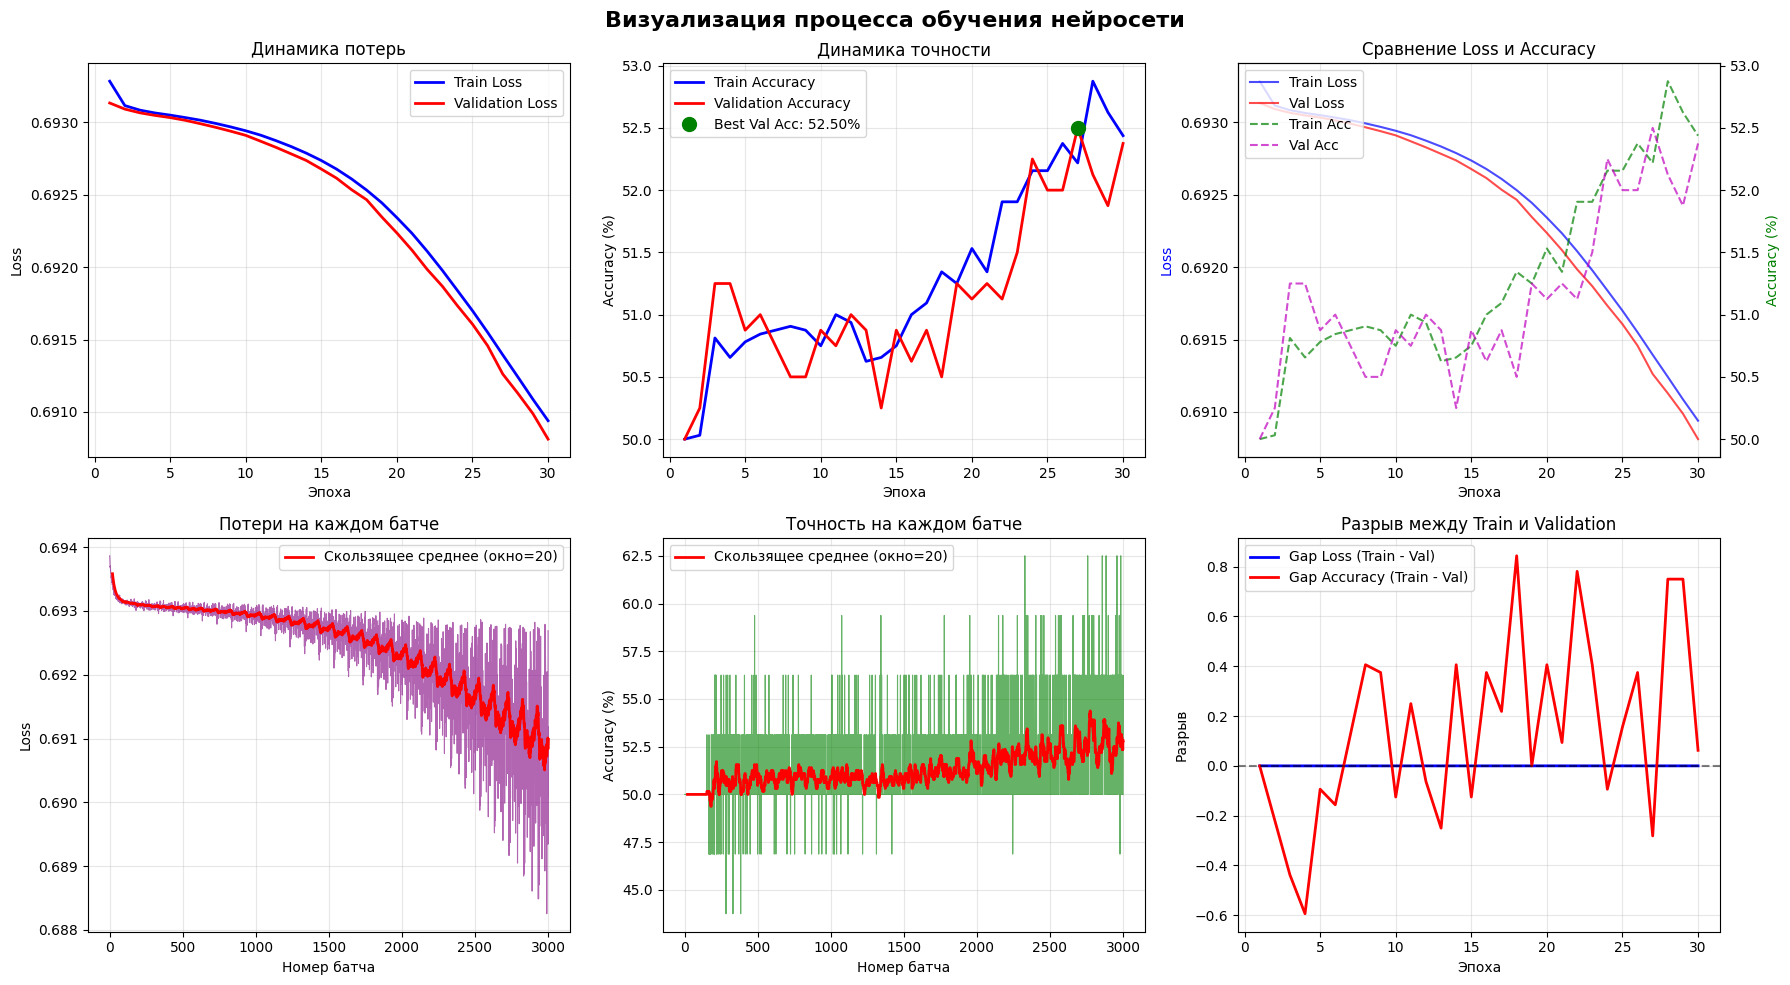


📊 ИТОГОВАЯ СТАТИСТИКА ОБУЧЕНИЯ
Всего эпох: 30

📍 Лучшие результаты на валидации:
  - Лучшая точность: 52.50% (эпоха 27)
  - Минимальные потери: 0.6908 (эпоха 30)

📍 Финальные результаты (эпоха 30):
  - Train Loss: 0.6909
  - Train Acc: 52.44%
  - Val Loss: 0.6908
  - Val Acc: 52.38%

📍 Анализ переобучения:
  - Разрыв по точности: 0.06%
  - Разрыв по Loss: 0.0001
  ✅ Переобучения не обнаружено

📁 Графики сохранены в файл 'training_visualization.png'


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Создаем фигуру с несколькими подграфиками
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Визуализация процесса обучения нейросети', fontsize=16, fontweight='bold')

# 1. График потерь (Loss) на тренировке и валидации
ax1 = axes[0, 0]
epochs = range(1, len(train_losses) + 1)
ax1.plot(epochs, train_losses, 'b-', label='Train Loss', linewidth=2)
ax1.plot(epochs, val_losses, 'r-', label='Validation Loss', linewidth=2)
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Loss')
ax1.set_title('Динамика потерь')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. График точности (Accuracy) на тренировке и валидации
ax2 = axes[0, 1]
ax2.plot(epochs, train_accuracies, 'b-', label='Train Accuracy', linewidth=2)
ax2.plot(epochs, val_accuracies, 'r-', label='Validation Accuracy', linewidth=2)
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Динамика точности')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Отметим лучшую точность на валидации
best_epoch = np.argmax(val_accuracies) + 1
ax2.plot(best_epoch, max(val_accuracies), 'go', markersize=10, 
         label=f'Best Val Acc: {max(val_accuracies):.2f}%')
ax2.legend()

# 3. Совмещенный график Loss и Accuracy
ax3 = axes[0, 2]
ax3_twin = ax3.twinx()
line1 = ax3.plot(epochs, train_losses, 'b-', label='Train Loss', linewidth=1.5, alpha=0.7)
line2 = ax3.plot(epochs, val_losses, 'r-', label='Val Loss', linewidth=1.5, alpha=0.7)
line3 = ax3_twin.plot(epochs, train_accuracies, 'g--', label='Train Acc', linewidth=1.5, alpha=0.7)
line4 = ax3_twin.plot(epochs, val_accuracies, 'm--', label='Val Acc', linewidth=1.5, alpha=0.7)

ax3.set_xlabel('Эпоха')
ax3.set_ylabel('Loss', color='b')
ax3_twin.set_ylabel('Accuracy (%)', color='g')
ax3.set_title('Сравнение Loss и Accuracy')

# Объединяем легенды
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax3.legend(lines, labels, loc='upper left')
ax3.grid(True, alpha=0.3)

# 4. График обучения по батчам (Loss)
ax4 = axes[1, 0]
batches = range(1, len(batch_losses) + 1)
ax4.plot(batches, batch_losses, 'purple', alpha=0.6, linewidth=0.8)
ax4.set_xlabel('Номер батча')
ax4.set_ylabel('Loss')
ax4.set_title('Потери на каждом батче')
ax4.grid(True, alpha=0.3)

# Добавим скользящее среднее для сглаживания
if len(batch_losses) > 10:
    window_size = min(20, len(batch_losses) // 10)
    moving_avg = np.convolve(batch_losses, np.ones(window_size)/window_size, mode='valid')
    ax4.plot(range(window_size, len(batch_losses) + 1), moving_avg, 
             'r-', linewidth=2, label=f'Скользящее среднее (окно={window_size})')
    ax4.legend()

# 5. График обучения по батчам (Accuracy)
ax5 = axes[1, 1]
ax5.plot(batches, [acc * 100 for acc in batch_accuracies], 'green', alpha=0.6, linewidth=0.8)
ax5.set_xlabel('Номер батча')
ax5.set_ylabel('Accuracy (%)')
ax5.set_title('Точность на каждом батче')
ax5.grid(True, alpha=0.3)

# Скользящее среднее для accuracy
if len(batch_accuracies) > 10:
    window_size = min(20, len(batch_accuracies) // 10)
    moving_avg_acc = np.convolve([acc * 100 for acc in batch_accuracies], 
                                 np.ones(window_size)/window_size, mode='valid')
    ax5.plot(range(window_size, len(batch_accuracies) + 1), moving_avg_acc, 
             'r-', linewidth=2, label=f'Скользящее среднее (окно={window_size})')
    ax5.legend()

# 6. Разрыв между Train и Validation (признак переобучения)
ax6 = axes[1, 2]
gap_loss = np.array(train_losses) - np.array(val_losses)
gap_acc = np.array(train_accuracies) - np.array(val_accuracies)

ax6.plot(epochs, gap_loss, 'b-', label='Gap Loss (Train - Val)', linewidth=2)
ax6.plot(epochs, gap_acc, 'r-', label='Gap Accuracy (Train - Val)', linewidth=2)
ax6.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax6.set_xlabel('Эпоха')
ax6.set_ylabel('Разрыв')
ax6.set_title('Разрыв между Train и Validation')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Дополнительная статистика
print("\n" + "="*50)
print("📊 ИТОГОВАЯ СТАТИСТИКА ОБУЧЕНИЯ")
print("="*50)
print(f"Всего эпох: {len(train_losses)}")
print(f"\n📍 Лучшие результаты на валидации:")
print(f"  - Лучшая точность: {max(val_accuracies):.2f}% (эпоха {np.argmax(val_accuracies) + 1})")
print(f"  - Минимальные потери: {min(val_losses):.4f} (эпоха {np.argmin(val_losses) + 1})")

print(f"\n📍 Финальные результаты (эпоха {len(train_losses)}):")
print(f"  - Train Loss: {train_losses[-1]:.4f}")
print(f"  - Train Acc: {train_accuracies[-1]:.2f}%")
print(f"  - Val Loss: {val_losses[-1]:.4f}")
print(f"  - Val Acc: {val_accuracies[-1]:.2f}%")

# Анализ переобучения
if len(train_losses) > 1:
    print(f"\n📍 Анализ переобучения:")
    final_gap_acc = train_accuracies[-1] - val_accuracies[-1]
    final_gap_loss = train_losses[-1] - val_losses[-1]
    
    print(f"  - Разрыв по точности: {final_gap_acc:.2f}%")
    print(f"  - Разрыв по Loss: {final_gap_loss:.4f}")
    
    if final_gap_acc > 5 or final_gap_loss > 0.5:
        print("  ⚠️ Обнаружены признаки переобучения!")
    else:
        print("  ✅ Переобучения не обнаружено")

# Сохраняем графики (опционально)
print("\n📁 Графики сохранены в файл 'training_visualization.png'")